In [52]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

## Practica 3
## Parte 1 (ECG)

In [2]:
def calcular_rms(x):
    x = np.array(x)          # Convertir la señal a arreglo
    N = len(x)               # Número de muestras
    rms = np.sqrt(np.sum(x**2) / N)
    return rms

In [7]:
data = loadmat('C:/Users/david/OneDrive/Desktop/Archivos Bioseñales/signals.mat')

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [24]:
# extraer señales
ecg_raw = data['ECG_asRecording'].flatten()
ecg_filt = data['ECG_filtered'].flatten()

In [25]:
fs = data['Fs'][0][0]   # frecuencia de muestreo
N = len(ecg_raw)

print("Número de muestras:", N)
print("Frecuencia de muestreo:", fs)

Número de muestras: 30720
Frecuencia de muestreo: 1024


In [13]:
duracion = N / fs

print(f"Duración de la señal: {duracion} segundos")

Duración de la señal: 30.0 segundos


In [21]:
t = np.arange(N) / fs

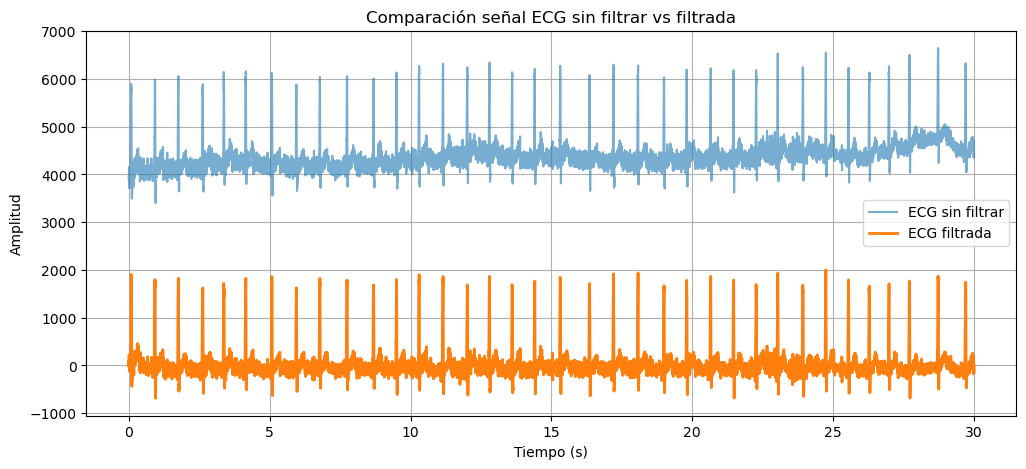

In [26]:
# graficar
plt.figure(figsize=(12,5))

plt.plot(t, ecg_raw, label="ECG sin filtrar", alpha=0.6)
plt.plot(t, ecg_filt, label="ECG filtrada", linewidth=2)

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación señal ECG sin filtrar vs filtrada")
plt.legend()
plt.grid()

plt.show()

## Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. 

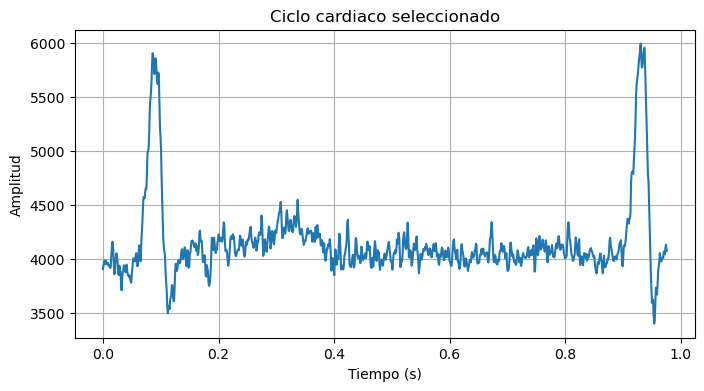

In [45]:
inicio = 0
fin = 1000

ciclo = ecg_raw[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Ciclo cardiaco seleccionado")
plt.grid()
plt.show()

In [46]:
promedio = np.mean(ciclo)
rms = calcular_rms(ciclo)
varianza = np.var(ciclo)
desv_std = np.std(ciclo)

print("Promedio:", promedio)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desv_std)

Promedio: 4146.573967773437
RMS: 4163.041009634786
Varianza: 136834.77768466578
Desviación estándar: 369.9118512357583


## Analizar los resultados

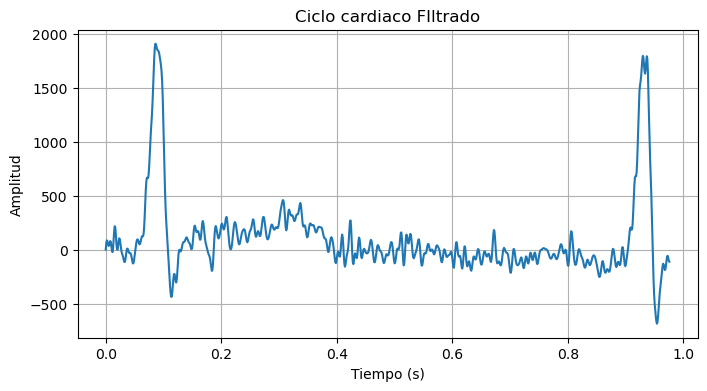

In [47]:
inicio = 0
fin = 1000

ciclo_filt = ecg_filt[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_filt)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Ciclo cardiaco FIltrado")
plt.grid()
plt.show()

In [48]:
promedio_f = np.mean(ciclo_filt)
rms_f = calcular_rms(ciclo_filt)
varianza_f = np.var(ciclo_filt)
desv_std_f = np.std(ciclo_filt)

print("Promedio:", promedio_f)
print("RMS:", rms_f)
print("Varianza:", varianza_f)
print("Desviación estándar:", desv_std_f)

Promedio: 98.76212104547919
RMS: 388.95193143334086
Varianza: 141529.6484123244
Desviación estándar: 376.20426421337174


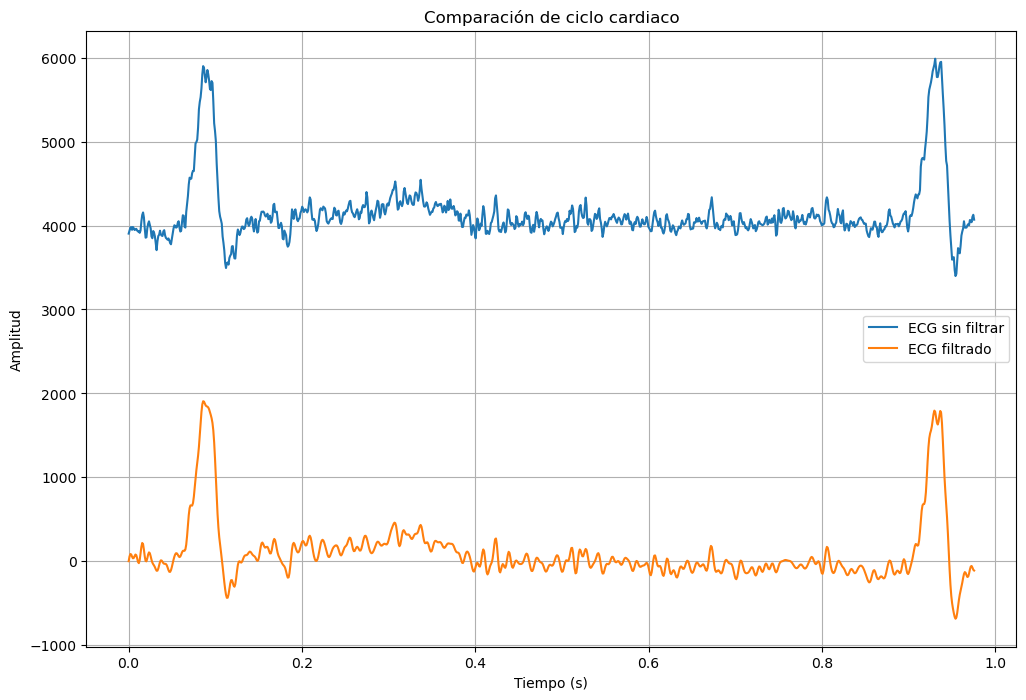

In [51]:
plt.figure(figsize=(12,8))

plt.plot(t_ciclo, ciclo, label="ECG sin filtrar")
plt.plot(t_ciclo, ciclo_filt, label="ECG filtrado")

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación de ciclo cardiaco")
plt.legend()
plt.grid()

plt.show()

## Compara resultados de los dos

In [54]:
peaks, _ = find_peaks(ecg_filt, distance=0.6*fs)

ciclos = []
promedios = []
varianzas = []

for i in range(15):
    inicio = peaks[i]
    fin = peaks[i+1]
    ciclo = ecg_filt[inicio:fin]
    ciclos.append(ciclo)

for ciclo in ciclos:
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

In [55]:
for i in range(15):
    print(f"Ciclo {i+1}")
    print("Promedio:", promedios[i])
    print("Varianza:", varianzas[i])
    print()

Ciclo 1
Promedio: 74.00995782055861
Varianza: 96684.31488232457

Ciclo 2
Promedio: -1.4625781779933433
Varianza: 104790.46548941819

Ciclo 3
Promedio: -10.433000231133212
Varianza: 82451.25107858983

Ciclo 4
Promedio: -20.975177997377532
Varianza: 46839.01969414558

Ciclo 5
Promedio: 40.87110478533409
Varianza: 114850.02006450474

Ciclo 6
Promedio: -27.94373421958412
Varianza: 58147.589511512415

Ciclo 7
Promedio: 0.43078685936823324
Varianza: 77707.28120177508

Ciclo 8
Promedio: 21.40785342744196
Varianza: 100268.18152771876

Ciclo 9
Promedio: -10.175289840749373
Varianza: 71784.95578593282

Ciclo 10
Promedio: 8.81210265962322
Varianza: 68481.05976260055

Ciclo 11
Promedio: -8.906158250191359
Varianza: 76088.38489781879

Ciclo 12
Promedio: 13.21327398140507
Varianza: 93862.69588330528

Ciclo 13
Promedio: -4.203262548456708
Varianza: 87951.50447594067

Ciclo 14
Promedio: -14.969688987125844
Varianza: 77022.13291729224

Ciclo 15
Promedio: 27.108316233516877
Varianza: 89636.93559971548



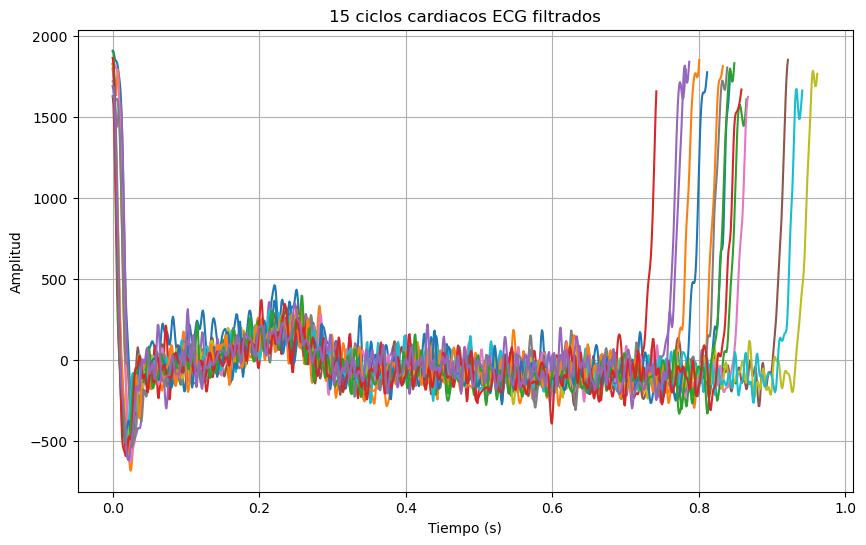

In [56]:
plt.figure(figsize=(10,6))

for i, ciclo in enumerate(ciclos):
    t_ciclo = np.arange(len(ciclo))/fs
    plt.plot(t_ciclo, ciclo)

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("15 ciclos cardiacos ECG filtrados")
plt.grid()
plt.show()

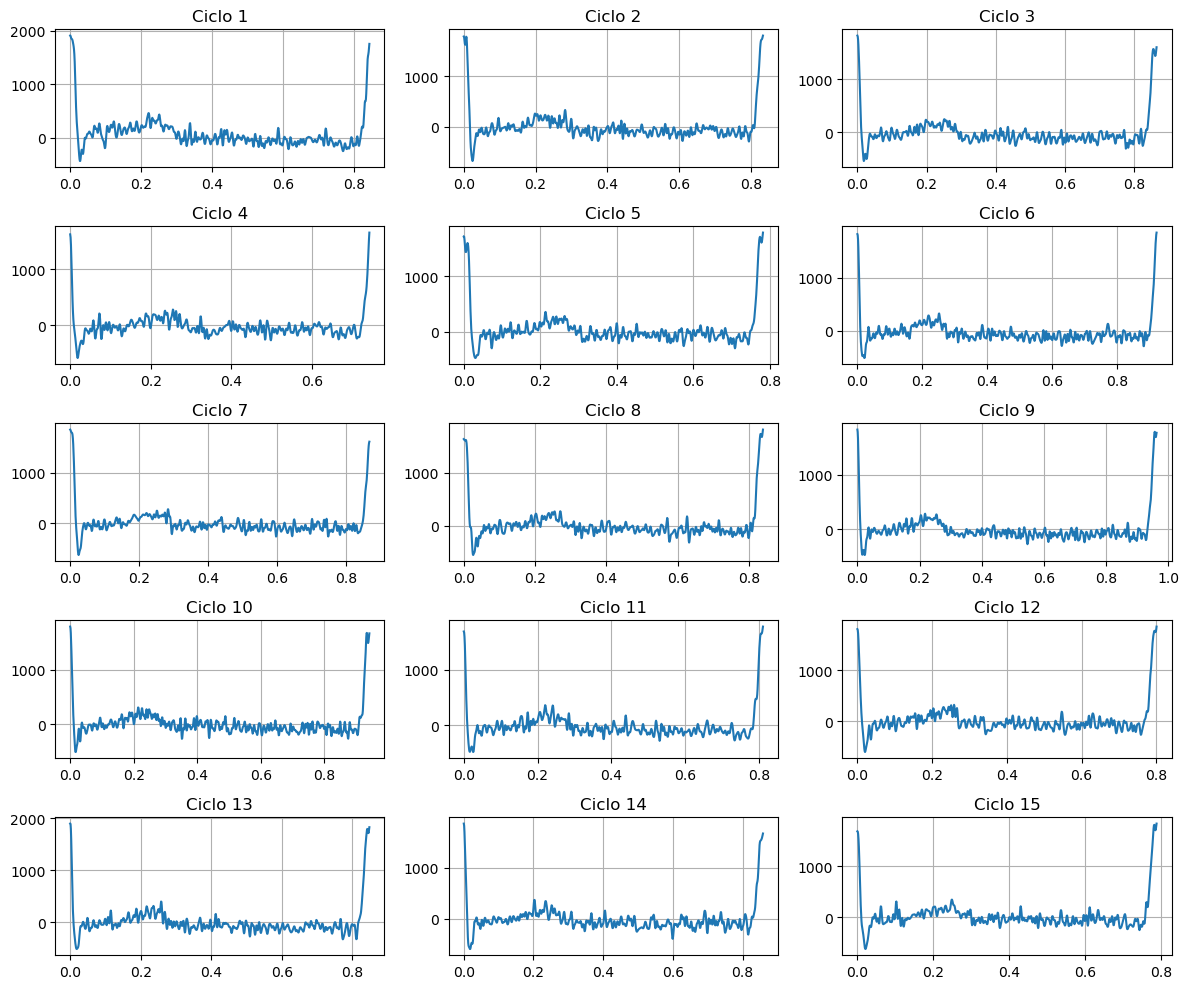

In [57]:
plt.figure(figsize=(12,10))

for i, ciclo in enumerate(ciclos):
    
    t_ciclo = np.arange(len(ciclo))/fs
    
    plt.subplot(5,3,i+1)
    plt.plot(t_ciclo, ciclo)
    plt.title(f"Ciclo {i+1}")
    plt.grid()

plt.tight_layout()
plt.show()

## analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?